# AvgGRM-diversity: greedy versus binary quadratic optimization

This notebook compares the greedy AvgGRM-diversity selection rule with an exact binary quadratic optimization formulation on small subsamples of one target-island source pool. The binary quadratic problem is solved as a linearized MILP with SciPy/HiGHS, so it is intended for small candidate sets only.

For each repeat, the notebook samples a fixed number of source candidates, solves both methods for several values of $k$ and $\lambda_{\mathrm{div}}$, and reports objective values, overlap, Jaccard similarity, and related summary statistics.

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr
from scipy import sparse
from scipy.optimize import Bounds, LinearConstraint, milp

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT

WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/Master_thesis')

## Configuration

The defaults are deliberately small. Increasing `N_CANDIDATES`, `N_REPEATS`, or the number of `(k, lambda)` settings can make the MILP substantially slower.

In [2]:
NPZ_PATH = PROJECT_ROOT / "Data" / "npz" / "snp_body_mass_ALL.npz"
GRM_RDS_PATH = PROJECT_ROOT / "Data" / "GRM" / "GRM_vanraden.rds"

MIN_COUNT = 20

# Use either a consecutive island code, e.g. 9, or set TARGET_ISLAND_LABEL to an original locality label such as "35".
TARGET_ISLAND_CODE = 9
TARGET_ISLAND_LABEL = None

N_CANDIDATES = 50
K_VALUES = [15]
LAMBDA_DIVS = [0.1, 0.5, 1.0]
N_REPEATS = 3

INCLUDE_DIAGONAL = True
SEED = 20260520

# HiGHS stops early if the time limit is hit. If that happens, the BQP column is the best incumbent found.
# For exploratory comparisons, a 1e-3 relative gap is usually enough. Tighten only when you need a final certificate.
MILP_TIME_LIMIT_SECONDS = 2000
MIP_REL_GAP = 1e-3
LOG_PROGRESS = True
PROGRESS_EVERY = 1

# Prints the internal HiGHS branch-and-bound log during each MILP solve.
# This is noisy, but it shows incumbent, bound, gap, nodes, and elapsed solver time.
MILP_SOLVER_LOG = True

## Load only what the comparison needs

The comparison uses IDs, locality, and the Van Raden GRM. It does not load the full SNP matrix.

In [3]:
def load_ids_locality_grm(npz_path: Path, grm_rds_path: Path, min_count: int = 20):
    with np.load(npz_path, allow_pickle=False) as data:
        ids = np.asarray(data["ids"]).astype(str)
        locality = np.asarray(data["locality"]).astype(str).ravel()

    if ids.shape[0] != locality.shape[0]:
        raise ValueError("ids and locality have different lengths")

    grm_res = pyreadr.read_r(str(grm_rds_path))
    grm_df = next(iter(grm_res.values()))
    grm_df.index = grm_df.index.astype(str)
    grm_df.columns = grm_df.columns.astype(str)

    ids_in = np.array([sample_id for sample_id in ids if sample_id in grm_df.index], dtype=str)
    if ids_in.size == 0:
        raise ValueError("No overlapping IDs between NPZ and GRM")

    if ids_in.size != ids.size or not np.array_equal(ids_in, ids):
        pos = {sample_id: i for i, sample_id in enumerate(ids)}
        keep = np.array([pos[sample_id] for sample_id in ids_in], dtype=int)
        ids = ids[keep]
        locality = locality[keep]

    grm_df = grm_df.loc[ids, ids]

    # Match src.data.load_data: merge Ranes (68) into Lauvoya (67), then drop islands below min_count.
    locality = np.where(locality == "68", "67", locality)
    labels, counts = np.unique(locality, return_counts=True)
    keep_labels = set(labels[counts >= min_count])
    keep = np.array([label in keep_labels for label in locality], dtype=bool)

    ids = ids[keep]
    locality = locality[keep]
    grm_df = grm_df.loc[ids, ids]

    labels = np.array(sorted(np.unique(locality), key=lambda x: int(x)), dtype=str)
    label_to_code = {label: code for code, label in enumerate(labels)}
    code_to_label = {code: label for label, code in label_to_code.items()}
    locality_codes = np.array([label_to_code[label] for label in locality], dtype=int)

    return grm_df.to_numpy(dtype=float), ids, locality_codes, code_to_label


grm, ids, locality, code_to_label = load_ids_locality_grm(NPZ_PATH, GRM_RDS_PATH, MIN_COUNT)
counts = pd.Series(locality).value_counts().sort_index().rename_axis("island_code").reset_index(name="n")
counts["island_label"] = counts["island_code"].map(code_to_label)
display(counts)
print(f"Loaded GRM with shape {grm.shape}")

,island_code,n,island_label
0,0,119,20
1,1,92,22
2,2,292,23
3,3,194,24
4,4,558,26
5,5,1078,27
6,6,356,28
7,7,259,33
8,8,158,34
9,9,166,35


Loaded GRM with shape (5697, 5697)


In [4]:
if TARGET_ISLAND_LABEL is not None:
    label_to_code = {label: code for code, label in code_to_label.items()}
    target_code = int(label_to_code[str(TARGET_ISLAND_LABEL)])
else:
    target_code = int(TARGET_ISLAND_CODE)

target_idx = np.flatnonzero(locality == target_code)
source_idx_all = np.flatnonzero(locality != target_code)

if target_idx.size == 0:
    raise ValueError(f"No samples found for target island code {target_code}")
if source_idx_all.size < N_CANDIDATES:
    raise ValueError(f"Only {source_idx_all.size} source candidates available, fewer than N_CANDIDATES={N_CANDIDATES}")

print(f"Target island code: {target_code}, label: {code_to_label[target_code]}")
print(f"Target samples: {target_idx.size}")
print(f"Source candidates before subsampling: {source_idx_all.size}")

Target island code: 9, label: 35
Target samples: 166
Source candidates before subsampling: 5531


## Objective and greedy selection

In [5]:
def q_value(selected, avg_grm_to_target, train_train_grm, lambda_div, include_diagonal=True):
    selected = np.asarray(selected, dtype=int)
    if selected.size == 0:
        return np.nan

    target_term = float(np.mean(avg_grm_to_target[selected]))
    block = train_train_grm[np.ix_(selected, selected)]
    if include_diagonal or selected.size == 1:
        internal_term = float(np.mean(block))
    else:
        internal_term = float((np.sum(block) - np.trace(block)) / (selected.size * (selected.size - 1)))
    return target_term - float(lambda_div) * internal_term


def subset_stats(selected, avg_grm_to_target, train_train_grm, lambda_div, include_diagonal=True):
    selected = np.asarray(selected, dtype=int)
    block = train_train_grm[np.ix_(selected, selected)]
    if include_diagonal or selected.size == 1:
        internal = float(np.mean(block))
    else:
        internal = float((np.sum(block) - np.trace(block)) / (selected.size * (selected.size - 1)))
    target = float(np.mean(avg_grm_to_target[selected]))
    return {
        "q": target - float(lambda_div) * internal,
        "avg_grm_to_target": target,
        "avg_internal_grm": internal,
    }


def greedy_avggrm_diversity(avg_grm_to_target, train_train_grm, k, lambda_div, include_diagonal=True):
    s = np.asarray(avg_grm_to_target, dtype=float)
    G = np.asarray(train_train_grm, dtype=float)
    n = s.size

    selected_mask = np.zeros(n, dtype=bool)
    relatedness_to_selected = np.zeros(n, dtype=float)
    diag = np.diag(G)
    target_sum = 0.0
    train_train_sum = 0.0
    order = []

    for step in range(int(k)):
        next_size = step + 1
        candidate_target_sum = target_sum + s
        candidate_avg_target = candidate_target_sum / next_size

        if include_diagonal:
            candidate_train_train_sum = train_train_sum + 2.0 * relatedness_to_selected + diag
            candidate_avg_train_train = candidate_train_train_sum / (next_size * next_size)
        else:
            candidate_train_train_sum = train_train_sum + 2.0 * relatedness_to_selected
            if next_size <= 1:
                candidate_avg_train_train = np.zeros(n, dtype=float)
            else:
                candidate_avg_train_train = candidate_train_train_sum / (next_size * (next_size - 1))

        candidate_q = candidate_avg_target - float(lambda_div) * candidate_avg_train_train
        candidate_q = np.where(selected_mask, -np.inf, candidate_q)
        best = int(np.argmax(candidate_q))

        order.append(best)
        selected_mask[best] = True
        target_sum = float(candidate_target_sum[best])
        train_train_sum = float(candidate_train_train_sum[best])
        relatedness_to_selected += G[:, best]

    return np.array(order, dtype=int)

## Binary quadratic optimization as a MILP

For fixed $k$, the objective can be written with binary variables $x_i$ and pair-product variables $y_{ij}=x_ix_j$. The MILP below uses the standard McCormick constraints for binary products. If the solver reaches optimality, this gives the exact optimum for the subsampled candidate set.

In [6]:
def solve_avggrm_diversity_bqp_milp(
    avg_grm_to_target,
    train_train_grm,
    k,
    lambda_div,
    include_diagonal=True,
    time_limit=10.0,
    mip_rel_gap=1e-8,
    verbose=False,
    solver_log=False,
):
    s = np.asarray(avg_grm_to_target, dtype=float).reshape(-1)
    G = np.asarray(train_train_grm, dtype=float)
    n = s.size
    k = int(k)
    if not (1 <= k <= n):
        raise ValueError("k must be between 1 and the number of candidates")

    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    m = len(pairs)
    n_vars = n + m
    n_constraints = 1 + 3 * m
    if verbose:
        print(
            f"MILP dimensions: n={n}, k={k}, lambda={lambda_div:g}, "
            f"variables={n_vars:,}, constraints={n_constraints:,}, "
            f"time_limit={time_limit}s, mip_rel_gap={mip_rel_gap}",
            flush=True,
        )

    # SciPy milp minimizes c @ v, so negate the maximization objective.
    x_coeff = s / float(k)
    y_coeff = np.zeros(m, dtype=float)
    if include_diagonal:
        x_coeff = x_coeff - float(lambda_div) * np.diag(G) / float(k * k)
        y_coeff = np.array([-float(lambda_div) * 2.0 * G[i, j] / float(k * k) for i, j in pairs], dtype=float)
    elif k > 1:
        y_coeff = np.array([-float(lambda_div) * 2.0 * G[i, j] / float(k * (k - 1)) for i, j in pairs], dtype=float)

    c = np.zeros(n_vars, dtype=float)
    c[:n] = -x_coeff
    c[n:] = -y_coeff

    row_idx = []
    col_idx = []
    data = []
    lb = []
    ub = []

    # Cardinality constraint: sum_i x_i = k.
    row = 0
    for i in range(n):
        row_idx.append(row)
        col_idx.append(i)
        data.append(1.0)
    lb.append(float(k))
    ub.append(float(k))
    row += 1

    # Product constraints for y_ij = x_i x_j.
    for pair_pos, (i, j) in enumerate(pairs):
        y_var = n + pair_pos

        # y_ij <= x_i
        row_idx.extend([row, row])
        col_idx.extend([y_var, i])
        data.extend([1.0, -1.0])
        lb.append(-np.inf)
        ub.append(0.0)
        row += 1

        # y_ij <= x_j
        row_idx.extend([row, row])
        col_idx.extend([y_var, j])
        data.extend([1.0, -1.0])
        lb.append(-np.inf)
        ub.append(0.0)
        row += 1

        # y_ij >= x_i + x_j - 1, equivalently y_ij - x_i - x_j >= -1.
        row_idx.extend([row, row, row])
        col_idx.extend([y_var, i, j])
        data.extend([1.0, -1.0, -1.0])
        lb.append(-1.0)
        ub.append(np.inf)
        row += 1

    A = sparse.coo_matrix((data, (row_idx, col_idx)), shape=(row, n_vars)).tocsr()
    constraints = LinearConstraint(A, np.array(lb, dtype=float), np.array(ub, dtype=float))
    integrality = np.zeros(n_vars, dtype=int)
    integrality[:n] = 1

    start = time.perf_counter()
    res = milp(
        c=c,
        integrality=integrality,
        bounds=Bounds(0.0, 1.0),
        constraints=constraints,
        options={
            "time_limit": float(time_limit),
            "mip_rel_gap": float(mip_rel_gap),
            "disp": bool(solver_log),
        },
    )
    elapsed = time.perf_counter() - start

    if res.x is None:
        return np.array([], dtype=int), res, elapsed

    x = np.asarray(res.x[:n])
    selected = np.flatnonzero(x > 0.5)
    if selected.size != k:
        selected = np.argsort(-x)[:k]

    return np.array(selected, dtype=int), res, elapsed

## Run repeated subsampling comparison

In [7]:
rng = np.random.default_rng(SEED)
rows = []
selected_sets = []

settings = [(repeat, lambda_div, k) for repeat in range(N_REPEATS) for lambda_div in LAMBDA_DIVS for k in K_VALUES]
total_jobs = len(settings)
job_idx = 0
run_start = time.perf_counter()

print(
    f"Running {total_jobs} MILP comparisons: "
    f"N_CANDIDATES={N_CANDIDATES}, repeats={N_REPEATS}, "
    f"k={K_VALUES}, lambda={LAMBDA_DIVS}, "
    f"time_limit={MILP_TIME_LIMIT_SECONDS}s, mip_rel_gap={MIP_REL_GAP}",
    flush=True,
)

for repeat in range(N_REPEATS):
    sampled_global_idx = rng.choice(source_idx_all, size=N_CANDIDATES, replace=False)
    sample_ids = ids[sampled_global_idx]

    avg_grm_to_target = grm[np.ix_(sampled_global_idx, target_idx)].mean(axis=1)
    train_train_grm = grm[np.ix_(sampled_global_idx, sampled_global_idx)]

    for lambda_div in LAMBDA_DIVS:
        for k in K_VALUES:
            job_idx += 1
            if LOG_PROGRESS and (job_idx == 1 or job_idx % PROGRESS_EVERY == 0):
                elapsed = time.perf_counter() - run_start
                print(
                    f"[{job_idx:>3}/{total_jobs}] repeat={repeat}, lambda={lambda_div:g}, k={k} "
                    f"starting after {elapsed:.1f}s",
                    flush=True,
                )

            greedy_sel = greedy_avggrm_diversity(
                avg_grm_to_target,
                train_train_grm,
                k=k,
                lambda_div=lambda_div,
                include_diagonal=INCLUDE_DIAGONAL,
            )
            bqp_sel, solver_result, solve_time = solve_avggrm_diversity_bqp_milp(
                avg_grm_to_target,
                train_train_grm,
                k=k,
                lambda_div=lambda_div,
                include_diagonal=INCLUDE_DIAGONAL,
                time_limit=MILP_TIME_LIMIT_SECONDS,
                mip_rel_gap=MIP_REL_GAP,
                verbose=LOG_PROGRESS,
                solver_log=MILP_SOLVER_LOG,
            )

            greedy_stats = subset_stats(greedy_sel, avg_grm_to_target, train_train_grm, lambda_div, INCLUDE_DIAGONAL)
            bqp_stats = subset_stats(bqp_sel, avg_grm_to_target, train_train_grm, lambda_div, INCLUDE_DIAGONAL)

            greedy_set = set(map(int, greedy_sel))
            bqp_set = set(map(int, bqp_sel))
            overlap = len(greedy_set & bqp_set)
            union = len(greedy_set | bqp_set)
            q_diff = bqp_stats["q"] - greedy_stats["q"]
            solver_mip_gap = getattr(solver_result, "mip_gap", np.nan)
            bqp_certified = bool(solver_result.success) and (
                not np.isfinite(solver_mip_gap) or solver_mip_gap <= MIP_REL_GAP + 1e-12
            )

            rows.append({
                "repeat": repeat,
                "target_code": target_code,
                "target_label": code_to_label[target_code],
                "n_candidates": N_CANDIDATES,
                "k": int(k),
                "lambda_div": float(lambda_div),
                "q_greedy": greedy_stats["q"],
                "q_bqp": bqp_stats["q"],
                "q_diff_bqp_minus_greedy": q_diff,
                "q_abs_diff": abs(q_diff),
                "q_rel_diff": q_diff / max(abs(bqp_stats["q"]), 1e-12),
                "bqp_better_than_greedy": bool(q_diff > 1e-10),
                "bqp_certified": bqp_certified,
                "overlap_n": overlap,
                "overlap_frac": overlap / float(k),
                "jaccard": overlap / float(union) if union else np.nan,
                "avg_target_greedy": greedy_stats["avg_grm_to_target"],
                "avg_target_bqp": bqp_stats["avg_grm_to_target"],
                "avg_internal_greedy": greedy_stats["avg_internal_grm"],
                "avg_internal_bqp": bqp_stats["avg_internal_grm"],
                "solver_success": bool(solver_result.success),
                "solver_status": int(solver_result.status),
                "solver_message": str(solver_result.message),
                "solver_mip_gap": solver_mip_gap,
                "solve_time_sec": solve_time,
            })

            if LOG_PROGRESS and (job_idx == 1 or job_idx % PROGRESS_EVERY == 0):
                status = "certified" if bqp_certified else "incumbent"
                elapsed = time.perf_counter() - run_start
                print(
                    f"[{job_idx:>3}/{total_jobs}] done in {solve_time:.2f}s, "
                    f"status={solver_result.status}, gap={solver_mip_gap:.4g}, "
                    f"{status}, q_diff={q_diff:.4g}, overlap={overlap}/{k}, "
                    f"elapsed={elapsed:.1f}s",
                    flush=True,
                )

            selected_sets.append({
                "repeat": repeat,
                "k": int(k),
                "lambda_div": float(lambda_div),
                "sample_ids": sample_ids,
                "greedy_local_idx": greedy_sel,
                "bqp_local_idx": bqp_sel,
                "greedy_ids": sample_ids[greedy_sel],
                "bqp_ids": sample_ids[bqp_sel],
            })

results_df = pd.DataFrame(rows)
display(results_df.head())
print(f"Finished {len(results_df)} comparisons in {time.perf_counter() - run_start:.1f}s")


Running 9 MILP comparisons: N_CANDIDATES=50, repeats=3, k=[15], lambda=[0.1, 0.5, 1.0], time_limit=2000s, mip_rel_gap=0.001
[  1/9] repeat=0, lambda=0.1, k=15 starting after 0.0s
MILP dimensions: n=50, k=15, lambda=0.1, variables=1,275, constraints=3,676, time_limit=2000s, mip_rel_gap=0.001
[  1/9] done in 0.09s, status=0, gap=0, certified, q_diff=0, overlap=15/15, elapsed=0.1s
[  2/9] repeat=0, lambda=0.5, k=15 starting after 0.1s
MILP dimensions: n=50, k=15, lambda=0.5, variables=1,275, constraints=3,676, time_limit=2000s, mip_rel_gap=0.001
[  2/9] done in 212.52s, status=0, gap=0.0009976, certified, q_diff=0.0001434, overlap=11/15, elapsed=212.6s
[  3/9] repeat=0, lambda=1, k=15 starting after 212.6s
MILP dimensions: n=50, k=15, lambda=1, variables=1,275, constraints=3,676, time_limit=2000s, mip_rel_gap=0.001
[  3/9] done in 1158.59s, status=0, gap=0.0009996, certified, q_diff=0.0002553, overlap=10/15, elapsed=1371.2s
[  4/9] repeat=1, lambda=0.1, k=15 starting after 1371.3s
MILP di

,repeat,target_code,target_label,n_candidates,k,lambda_div,q_greedy,q_bqp,q_diff_bqp_minus_greedy,q_abs_diff,q_rel_diff,bqp_better_than_greedy,bqp_certified,overlap_n,overlap_frac,jaccard,avg_target_greedy,avg_target_bqp,avg_internal_greedy,avg_internal_bqp,solver_success,solver_status,solver_message,solver_mip_gap,solve_time_sec
0,0,9,35,50,15,0.1,-0.004192,-0.004192,0.000000e+00,0.000000e+00,0.000000e+00,False,True,15,1.000000,1.000000,0.002799,0.002799,0.069901,0.069901,True,0,Optimization terminated successfully. (HiGHS S...,0.000000,0.094409
1,0,9,35,50,15,0.5,-0.030931,-0.030787,1.433822e-04,1.433822e-04,4.657185e-03,True,True,11,0.733333,0.578947,0.001077,0.001572,0.064016,0.064719,True,0,Optimization terminated successfully. (HiGHS S...,0.000998,212.515542
2,0,9,35,50,15,1.0,-0.062345,-0.062090,2.553022e-04,2.553022e-04,4.111825e-03,True,True,10,0.666667,0.500000,-0.000147,0.000209,0.062198,0.062298,True,0,Optimization terminated successfully. (HiGHS S...,0.001000,1158.593749
3,1,9,35,50,15,0.1,0.001670,0.001670,-2.602085e-18,2.602085e-18,-1.558430e-15,False,True,15,1.000000,1.000000,0.008460,0.008460,0.067908,0.067908,True,0,Optimization terminated successfully. (HiGHS S...,0.000000,0.062863
4,1,9,35,50,15,0.5,-0.024738,-0.024744,-6.073507e-06,6.073507e-06,-2.454536e-04,False,True,13,0.866667,0.764706,0.006962,0.007099,0.063400,0.063687,True,0,Optimization terminated successfully. (HiGHS S...,0.000991,68.726311


Finished 9 comparisons in 1943.6s


## Summary tables

In [8]:
summary = (
    results_df
    .groupby(["lambda_div", "k"], as_index=False)
    .agg(
        n=("repeat", "count"),
        q_greedy_mean=("q_greedy", "mean"),
        q_bqp_mean=("q_bqp", "mean"),
        q_diff_mean=("q_diff_bqp_minus_greedy", "mean"),
        q_diff_sd=("q_diff_bqp_minus_greedy", "std"),
        q_diff_max=("q_diff_bqp_minus_greedy", "max"),
        overlap_frac_mean=("overlap_frac", "mean"),
        overlap_frac_sd=("overlap_frac", "std"),
        jaccard_mean=("jaccard", "mean"),
        solve_time_mean=("solve_time_sec", "mean"),
        solver_success_rate=("solver_success", "mean"),
        bqp_certified_rate=("bqp_certified", "mean"),
    )
)
display(summary)

,lambda_div,k,n,q_greedy_mean,q_bqp_mean,q_diff_mean,q_diff_sd,q_diff_max,overlap_frac_mean,overlap_frac_sd,jaccard_mean,solve_time_mean,solver_success_rate,bqp_certified_rate
0,0.1,15,3,-0.000178,-0.000178,-2.023844e-18,1.805557e-18,0.000000,1.000000,0.000000,1.000000,0.066039,1.0,1.0
1,0.5,15,3,-0.027053,-0.026942,1.112647e-04,1.050295e-04,0.000196,0.844444,0.101835,0.739551,116.200529,1.0,1.0
2,1.0,15,3,-0.058766,-0.058451,3.143796e-04,1.490659e-04,0.000484,0.733333,0.066667,0.581871,531.533124,1.0,1.0


In [9]:
failed = results_df.loc[
    ~results_df["bqp_certified"],
    ["repeat", "lambda_div", "k", "solver_status", "solver_message", "solver_mip_gap", "solve_time_sec", "q_diff_bqp_minus_greedy"],
]
display(failed)

if failed.empty:
    print("All MILP solves were certified within the requested gap.")
else:
    print("Some MILP solves were not certified; those BQP results are best incumbents, not guaranteed optima.")


,repeat,lambda_div,k,solver_status,solver_message,solver_mip_gap,solve_time_sec,q_diff_bqp_minus_greedy


All MILP solves were certified within the requested gap.


## Plots

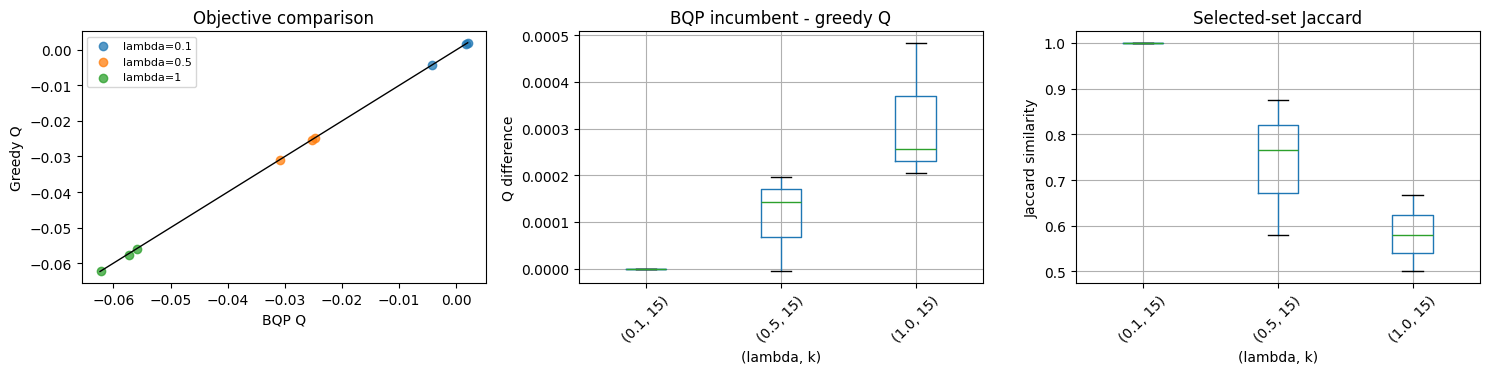

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for lambda_div, group in results_df.groupby("lambda_div"):
    axes[0].scatter(group["q_bqp"], group["q_greedy"], label=f"lambda={lambda_div:g}", alpha=0.75)
lims = [min(results_df["q_bqp"].min(), results_df["q_greedy"].min()), max(results_df["q_bqp"].max(), results_df["q_greedy"].max())]
axes[0].plot(lims, lims, color="black", linewidth=1)
axes[0].set_xlabel("BQP Q")
axes[0].set_ylabel("Greedy Q")
axes[0].set_title("Objective comparison")
axes[0].legend(fontsize=8)

results_df.boxplot(column="q_diff_bqp_minus_greedy", by=["lambda_div", "k"], ax=axes[1], rot=45)
axes[1].set_title("BQP incumbent - greedy Q")
axes[1].set_xlabel("(lambda, k)")
axes[1].set_ylabel("Q difference")

results_df.boxplot(column="jaccard", by=["lambda_div", "k"], ax=axes[2], rot=45)
axes[2].set_title("Selected-set Jaccard")
axes[2].set_xlabel("(lambda, k)")
axes[2].set_ylabel("Jaccard similarity")

fig.suptitle("")
fig.tight_layout()
plt.show()

## Inspect the largest disagreements

In [11]:
worst = results_df.sort_values(["q_diff_bqp_minus_greedy", "jaccard"], ascending=[False, True]).head(10)
display(worst[[
    "repeat", "lambda_div", "k", "q_greedy", "q_bqp", "q_diff_bqp_minus_greedy", "overlap_frac", "jaccard",
    "avg_target_greedy", "avg_target_bqp", "avg_internal_greedy", "avg_internal_bqp", "solver_success", "solver_mip_gap"
]])

if not worst.empty:
    row = worst.iloc[0]
    match = next(
        item for item in selected_sets
        if item["repeat"] == row["repeat"] and item["k"] == row["k"] and item["lambda_div"] == row["lambda_div"]
    )
    greedy_only = sorted(set(match["greedy_ids"]) - set(match["bqp_ids"]))
    bqp_only = sorted(set(match["bqp_ids"]) - set(match["greedy_ids"]))
    print("Worst case IDs selected only by greedy:")
    print(greedy_only)
    print("Worst case IDs selected only by BQP:")
    print(bqp_only)

,repeat,lambda_div,k,q_greedy,q_bqp,q_diff_bqp_minus_greedy,overlap_frac,jaccard,avg_target_greedy,avg_target_bqp,avg_internal_greedy,avg_internal_bqp,solver_success,solver_mip_gap
8,2,1.0,15,-0.057830,-0.057346,4.839291e-04,0.733333,0.578947,0.005281,0.005797,0.063111,0.063143,True,0.000986
2,0,1.0,15,-0.062345,-0.062090,2.553022e-04,0.666667,0.500000,-0.000147,0.000209,0.062198,0.062298,True,0.001000
5,1,1.0,15,-0.056122,-0.055918,2.039075e-04,0.800000,0.666667,0.005229,0.005509,0.061351,0.061428,True,0.000997
7,2,0.5,15,-0.025490,-0.025294,1.964855e-04,0.933333,0.875000,0.007849,0.007774,0.066678,0.066136,True,0.000884
1,0,0.5,15,-0.030931,-0.030787,1.433822e-04,0.733333,0.578947,0.001077,0.001572,0.064016,0.064719,True,0.000998
0,0,0.1,15,-0.004192,-0.004192,0.000000e+00,1.000000,1.000000,0.002799,0.002799,0.069901,0.069901,True,0.000000
3,1,0.1,15,0.001670,0.001670,-2.602085e-18,1.000000,1.000000,0.008460,0.008460,0.067908,0.067908,True,0.000000
6,2,0.1,15,0.001987,0.001987,-3.469447e-18,1.000000,1.000000,0.009231,0.009231,0.072440,0.072440,True,0.000000
4,1,0.5,15,-0.024738,-0.024744,-6.073507e-06,0.866667,0.764706,0.006962,0.007099,0.063400,0.063687,True,0.000991


Worst case IDs selected only by greedy:
[np.str_('8681454'), np.str_('8981185'), np.str_('8N14938'), np.str_('8N28794')]
Worst case IDs selected only by BQP:
[np.str_('8730945'), np.str_('8732656'), np.str_('8939070'), np.str_('8P11528')]
